# DL-01 · PyTorch Foundations and Training Loops

**Prerequisites:** FND-04, CML-01, CML-02, MLE-02, and EVAL-01  
**Estimated study time:** 8–10 hours, including practice  
**Next lesson:** DL-02 · Neural Networks from Scratch

PyTorch does not replace the mathematics learned earlier. It represents arrays as
tensors, records differentiable operations, calculates gradients, registers model
parameters, and applies optimizer updates at scale.

We begin with linear regression because you already understand its prediction,
squared loss, and gradient descent. That lets us inspect what PyTorch does without
hiding new neural-network ideas inside framework syntax.

### Scope boundary

This lesson covers tensor mechanics, devices, autograd, modules, loaders, loops,
validation checkpoints, and serialization. It defers multilayer networks to DL-02,
general backpropagation to DL-03, stable deep training to DL-04, and sequence or
attention tensors to their later lessons.


> **Canonical learner route · module DL-01 of 67**
>
> Required prerequisites: **FND-04, CML-02, MLE-02, MLE-06, EVAL-01** · Previous: **MLE-06** ·
> Next after mastery: **DL-02** · Expected first-pass workload:
> **5–8 hours**
>
> **Core path:** intuition, objectives, foundations, runnable implementation,
> failure modes, and assessed exercises. **Extension path:** history, production,
> tradeoffs, and interview material may be revisited after the core pass.
> Do not continue merely because every cell ran. Continue when you can complete
> the independent exercise and teach-back without notes. The canonical route in
> `docs/CURRICULUM_PATH.json` is authoritative when section-local file order and
> prerequisite order differ.


## 1 · What you will be able to do

By the end, you will be able to:

- inspect a tensor's value, shape, dtype, device, and gradient role;
- explain copying versus shared memory when converting from NumPy;
- index, slice, reshape, transpose, and restore contiguous layout;
- predict broadcasting and matrix-multiplication shapes before running code;
- select CPU, CUDA, or Apple MPS safely and move model plus batches together;
- trace a small autograd graph and demonstrate gradient accumulation;
- distinguish `detach`, `no_grad`, and `inference_mode`;
- register trainable tensors with `nn.Parameter` and `nn.Module`;
- explain a `Dataset`, `DataLoader`, batch, step, and epoch;
- write commented training and evaluation functions;
- select and restore a checkpoint using validation only;
- save weights, optimizer state, and metadata;
- prove that a loaded model reproduces predictions;
- evaluate one restored checkpoint once on sealed test data.

### Learning path

```mermaid
flowchart LR
    A[Tensor contract] --> B[Shape operations]
    B --> C[Broadcast and matmul]
    C --> D[Device]
    D --> E[Autograd]
    E --> F[Parameter and Module]
    F --> G[Dataset and DataLoader]
    G --> H[Training loop]
    H --> I[Validation checkpoint]
    I --> J[Save and restore]
    J --> K[One sealed test]
```

Tensor shapes  
→ required before layers  
→ because most framework errors are broken shape contracts.

Autograd  
→ required before optimizers  
→ because an optimizer reads parameter gradients; it does not calculate them.

Validation checkpoints  
→ required before test  
→ because test data cannot choose an epoch or model state.


## 2 · A tensor has five parts to inspect

A tensor is an array plus a contract:

1. **value:** stored numbers;
2. **shape:** axis lengths;
3. **dtype:** numerical representation;
4. **device:** CPU or accelerator memory;
5. **gradient role:** whether autograd tracks operations for derivatives.

Common dtypes:

| Data | Typical dtype | Reason |
|---|---|---|
| features and model weights | `float32` | efficient differentiable arithmetic |
| class indices for cross-entropy | `long` / `int64` | each value is a class ID |
| boolean masks | `bool` | selection, not numeric magnitude |
| high-precision numerical checks | `float64` | lower rounding error, higher cost |

`torch.from_numpy(array)` normally shares CPU memory with a compatible NumPy array.
`torch.tensor(array)` makes a copy. Shared memory is useful but can surprise a
beginner when mutation in one object changes the other.


In [1]:
import copy
import io
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

def seed_everything(seed=42):
    '''Seed the random generators used in this CPU-first lesson.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(42)

numpy_values = np.array([1.0, 2.0, 3.0], dtype=np.float32)
shared_tensor = torch.from_numpy(numpy_values)
copied_tensor = torch.tensor(numpy_values)
numpy_values[0] = 99.0

class_indices = torch.tensor([0, 2, 1], dtype=torch.long)
selection_mask = torch.tensor([True, False, True], dtype=torch.bool)

print("shared after NumPy mutation:", shared_tensor)
print("copied after NumPy mutation:", copied_tensor)
print("class indices:", class_indices.dtype)
print("mask:", selection_mask.dtype)
print("gradient tracked:", shared_tensor.requires_grad)

assert shared_tensor[0].item() == 99.0
assert copied_tensor[0].item() == 1.0


shared after NumPy mutation: tensor([99.,  2.,  3.])
copied after NumPy mutation: tensor([1., 2., 3.])
class indices: torch.int64
mask: torch.bool
gradient tracked: False


## 3 · Indexing and shape transformations preserve meaning only when intentional

For a feature batch shaped `(B, d)`, $B$ is number of examples and $d$ is features
per example.

- `tensor[0]` removes the first axis and selects one example;
- `tensor[0:1]` keeps a batch axis of length one;
- `reshape` changes the view of axes when possible and may copy when required;
- `transpose` swaps axes and often creates a non-contiguous view;
- `contiguous()` creates memory laid out in the current visible order.

Losing the batch axis is a common batch-size-one bug. Write the meaning of every
axis before calling `squeeze`, `reshape`, or `transpose`.


In [2]:
feature_batch = torch.arange(24, dtype=torch.float32).reshape(4, 6)
one_example_without_batch_axis = feature_batch[0]
one_example_with_batch_axis = feature_batch[0:1]
transposed_batch = feature_batch.transpose(0, 1)
restored_flat = transposed_batch.contiguous().view(-1)

print("batch:", feature_batch.shape)
print("index [0]:", one_example_without_batch_axis.shape)
print("slice [0:1]:", one_example_with_batch_axis.shape)
print("transposed:", transposed_batch.shape, "contiguous:", transposed_batch.is_contiguous())
print("contiguous flat:", restored_flat.shape)

assert one_example_without_batch_axis.shape == (6,)
assert one_example_with_batch_axis.shape == (1, 6)
assert transposed_batch.shape == (6, 4)


batch: torch.Size([4, 6])
index [0]: torch.Size([6])
slice [0:1]: torch.Size([1, 6])
transposed: torch.Size([6, 4]) contiguous: False
contiguous flat: torch.Size([24])


## 4 · Broadcasting and matrix multiplication power linear layers

For inputs $X\in\mathbb R^{B\times d}$, weights
$W\in\mathbb R^{d\times c}$, and bias $b\in\mathbb R^c$:

$$
Z=XW+b
$$

**Symbols:** $B$ is batch size; $d$ is input-feature count; $c$ is output count;
and $Z\in\mathbb R^{B\times c}$ contains one output row per example.

The bias has shape `(c,)`. Broadcasting behaves as if that bias were repeated over
all $B$ rows, without manually storing the repeats.

Broadcasting compares shapes from the right. Dimensions are compatible when equal
or when one of them is `1`. A successful broadcast can still be logically wrong, so
shape compatibility is necessary but not sufficient.


In [3]:
small_inputs = torch.tensor(
    [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]],
    dtype=torch.float32,
)
small_weights = torch.tensor(
    [[1.0, 0.0], [0.0, 1.0], [1.0, -1.0]],
    dtype=torch.float32,
)
small_bias = torch.tensor([0.5, -0.5], dtype=torch.float32)

matrix_product = small_inputs @ small_weights
linear_outputs = matrix_product + small_bias

print("input @ weights:", matrix_product.shape)
print(matrix_product)
print("after broadcast bias:", linear_outputs.shape)
print(linear_outputs)

assert linear_outputs.shape == (2, 2)
assert torch.allclose(linear_outputs[0], torch.tensor([4.5, -1.5]))


input @ weights: torch.Size([2, 2])
tensor([[ 4., -1.],
        [10., -1.]])
after broadcast bias: torch.Size([2, 2])
tensor([[ 4.5000, -1.5000],
        [10.5000, -1.5000]])


## 5 · A device move must include both model and data

Tensors on different devices cannot participate in ordinary operations. Choose one
device, move the model once, and move every batch inside the loop.

- CUDA uses supported NVIDIA GPUs;
- MPS uses supported Apple Silicon GPUs;
- CPU is the portable fallback.

Accelerators are not automatically faster for tiny workloads because transfer and
launch overhead can dominate. Numerical results may also differ slightly across
hardware and kernels, so reproducibility means bounded, documented behavior—not a
promise of identical bits everywhere.


In [4]:
def choose_compute_device():
    '''Prefer CUDA, then Apple MPS, otherwise use CPU.'''
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


compute_device = choose_compute_device()
device_example = torch.ones(3, dtype=torch.float32).to(compute_device)

print("selected device:", compute_device)
print("example tensor device:", device_example.device)

assert device_example.device.type == compute_device.type


selected device: mps
example tensor device: mps:0


## 6 · Autograd calculates gradients; it does not update parameters

For $L(w)=(w-5)^2$:

$$
\frac{dL}{dw}=2(w-5)
$$

At $w=2$, the gradient is `-6`. Calling `backward()` sends derivative information
backward through the recorded operations and adds it to leaf tensor `.grad`.

Gradients accumulate by design. This supports intentional gradient accumulation,
but ordinary training must clear old gradients before the next backward pass.

- `detach()` returns a tensor disconnected from the current graph;
- `no_grad()` disables recording inside a block;
- `inference_mode()` is a stronger evaluation context with additional optimizations.
None replaces `model.eval()`, which changes module behavior such as dropout.


In [5]:
scalar_weight = torch.tensor(2.0, requires_grad=True)

first_loss = (scalar_weight - 5.0) ** 2
first_loss.backward()
first_gradient = scalar_weight.grad.item()

# A new graph adds another gradient to the existing .grad value.
second_loss = (scalar_weight - 5.0) ** 2
second_loss.backward()
accumulated_gradient = scalar_weight.grad.item()

scalar_weight.grad.zero_()
cleared_gradient = scalar_weight.grad.item()

vector = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
vector_loss = (vector ** 2).sum()
vector_loss.backward()
detached_vector = vector.detach()

with torch.no_grad():
    untracked_result = vector * 10

print("first gradient:", first_gradient)
print("after second backward:", accumulated_gradient)
print("after zeroing:", cleared_gradient)
print("vector gradient:", vector.grad)
print("detached requires_grad:", detached_vector.requires_grad)
print("no_grad result requires_grad:", untracked_result.requires_grad)

assert first_gradient == -6.0
assert accumulated_gradient == -12.0
assert torch.allclose(vector.grad, torch.tensor([2.0, 4.0, 6.0]))


first gradient: -6.0
after second backward: -12.0
after zeroing: 0.0
vector gradient: tensor([2., 4., 6.])
detached requires_grad: False
no_grad result requires_grad: False


## 7 · Parameters and modules make trainable structure explicit

`nn.Parameter` is a tensor registered as trainable when attached to an `nn.Module`.
`model.parameters()` discovers registered parameters for an optimizer.

A custom module defines structure in `__init__` and computation in `forward`. Calling
`model(inputs)` invokes framework hooks around `forward`; call the model rather than
calling `forward` directly.

`nn.Linear(d,c)` stores weights with shape `(c,d)`, so its computation is
`inputs @ weight.T + bias`. This storage orientation differs from the mathematical
`(d,c)` convention but produces the same batched affine map.


In [6]:
class TransparentLinearRegression(nn.Module):
    def __init__(self, input_feature_count):
        super().__init__()
        self.linear = nn.Linear(input_feature_count, 1)

    def forward(self, inputs):
        return self.linear(inputs)


transparent_model = TransparentLinearRegression(input_feature_count=3)
with torch.no_grad():
    transparent_model.linear.weight.copy_(torch.tensor([[2.0, -1.0, 0.5]]))
    transparent_model.linear.bias.copy_(torch.tensor([3.0]))

module_inputs = torch.tensor([[1.0, 2.0, 4.0], [2.0, 0.0, 1.0]])
manual_module_outputs = module_inputs @ transparent_model.linear.weight.T + transparent_model.linear.bias
framework_module_outputs = transparent_model(module_inputs)

print("named parameters:")
for parameter_name, parameter in transparent_model.named_parameters():
    print(parameter_name, tuple(parameter.shape), "requires_grad=", parameter.requires_grad)
print("manual outputs:", manual_module_outputs.flatten())
print("module outputs:", framework_module_outputs.flatten())

assert torch.allclose(manual_module_outputs, framework_module_outputs)


named parameters:
linear.weight (1, 3) requires_grad= True
linear.bias (1,) requires_grad= True
manual outputs: tensor([5.0000, 7.5000], grad_fn=<ViewBackward0>)
module outputs: tensor([5.0000, 7.5000], grad_fn=<ViewBackward0>)


## 8 · Split and preprocess before creating loaders

We predict energy use from three numerical measurements using a relationship linear
regression can learn. The target is meaningful, unlike unrelated random labels.

Data responsibilities:

- training rows fit preprocessing and update parameters;
- validation rows select the checkpoint epoch;
- test rows remain sealed until the final section.

A `TensorDataset` returns aligned tensor rows. A `DataLoader` groups them into
batches. Training shuffles; validation and test do not need to shuffle.

**Batch:** examples processed together.  
**Step:** one optimizer update.  
**Epoch:** one pass through the training loader.


In [7]:
data_generator = torch.Generator().manual_seed(42)
all_regression_features = torch.randn(1200, 3, generator=data_generator)
true_weights = torch.tensor([[3.0], [-2.0], [1.5]])
true_bias = 4.0
target_noise = 0.35 * torch.randn(1200, 1, generator=data_generator)
all_regression_targets = all_regression_features @ true_weights + true_bias + target_noise

shuffled_indices = torch.randperm(1200, generator=torch.Generator().manual_seed(42))
train_indices = shuffled_indices[:720]
validation_indices = shuffled_indices[720:960]
sealed_test_indices = shuffled_indices[960:]

raw_train_features = all_regression_features[train_indices]
raw_validation_features = all_regression_features[validation_indices]
raw_sealed_test_features = all_regression_features[sealed_test_indices]
train_targets = all_regression_targets[train_indices]
validation_targets = all_regression_targets[validation_indices]
sealed_test_targets = all_regression_targets[sealed_test_indices]

# Fit preprocessing statistics on training features only.
training_feature_mean = raw_train_features.mean(dim=0, keepdim=True)
training_feature_std = raw_train_features.std(dim=0, keepdim=True)
train_features = (raw_train_features - training_feature_mean) / training_feature_std
validation_features = (raw_validation_features - training_feature_mean) / training_feature_std
sealed_test_features = (raw_sealed_test_features - training_feature_mean) / training_feature_std

train_dataset = TensorDataset(train_features, train_targets)
validation_dataset = TensorDataset(validation_features, validation_targets)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)
validation_loader = DataLoader(validation_dataset, batch_size=128, shuffle=False)

first_feature_batch, first_target_batch = next(iter(train_loader))
print("training / validation / sealed test:", len(train_indices), len(validation_indices), len(sealed_test_indices))
print("first batch shapes:", first_feature_batch.shape, first_target_batch.shape)
print("training standardized means:", train_features.mean(dim=0).round(decimals=4))
print("test status: sealed")

assert first_feature_batch.shape[1:] == (3,)
assert first_target_batch.shape[1:] == (1,)
assert set(train_indices.tolist()).isdisjoint(sealed_test_indices.tolist())


training / validation / sealed test: 720 240 240
first batch shapes: torch.Size([64, 3]) torch.Size([64, 1])
training standardized means: tensor([0., 0., -0.])
test status: sealed


## 9 · Loss, backward, and optimizer step have separate jobs

Mean squared error for a batch is:

$$
\operatorname{MSE}=\frac{1}{B}\sum_{i=1}^{B}(y_i-\hat y_i)^2
$$

**Symbols:** $B$ is batch size; $y_i$ is target; and $\hat y_i$ is prediction.

One ordinary training step is:

1. clear old gradients;
2. run the forward pass;
3. calculate scalar loss;
4. call `backward()` to populate gradients;
5. call `step()` to update parameters.

For SGD, $\theta\leftarrow\theta-\eta\nabla_\theta L$, where $\theta$ is a
parameter, $\eta$ is learning rate, and $\nabla_\theta L$ is its gradient. Autograd
calculates the gradient; the optimizer applies the update.


In [8]:
step_model = TransparentLinearRegression(3)
step_optimizer = torch.optim.SGD(step_model.parameters(), lr=0.05)
step_loss_function = nn.MSELoss()
step_features, step_targets = first_feature_batch, first_target_batch

weight_before_step = step_model.linear.weight.detach().clone()
step_optimizer.zero_grad(set_to_none=True)
step_predictions = step_model(step_features)
step_loss = step_loss_function(step_predictions, step_targets)
step_loss.backward()
weight_gradient = step_model.linear.weight.grad.detach().clone()
expected_weight_after_step = weight_before_step - 0.05 * weight_gradient
step_optimizer.step()

print("batch loss:", round(step_loss.item(), 4))
print("weight gradient shape:", weight_gradient.shape)
print("optimizer matches manual SGD update:", torch.allclose(step_model.linear.weight, expected_weight_after_step))

assert torch.allclose(step_model.linear.weight, expected_weight_after_step)


batch loss: 24.0185
weight gradient shape: torch.Size([1, 3])
optimizer matches manual SGD update: True


## 10 · Training and evaluation are different programs

Training enables training behavior, records gradients, and updates parameters.
Evaluation enables evaluation behavior, disables gradient recording, and never calls
an optimizer.

`model.eval()` matters for dropout and batch normalization. `inference_mode()`
matters for gradient recording and execution overhead. Use both during evaluation.

Loss aggregation must weight by example count. Averaging batch averages equally is
wrong when the final batch is smaller.


In [9]:
dropout_demo = nn.Dropout(p=0.5)
dropout_inputs = torch.ones(100)
dropout_demo.train()
training_dropout_output = dropout_demo(dropout_inputs)
dropout_demo.eval()
evaluation_dropout_output_1 = dropout_demo(dropout_inputs)
evaluation_dropout_output_2 = dropout_demo(dropout_inputs)

print("training output differs from all ones:", not torch.allclose(training_dropout_output, dropout_inputs))
print("evaluation outputs repeat:", torch.allclose(evaluation_dropout_output_1, evaluation_dropout_output_2))
print("evaluation returns unchanged input:", torch.allclose(evaluation_dropout_output_1, dropout_inputs))

assert torch.allclose(evaluation_dropout_output_1, dropout_inputs)


training output differs from all ones: True
evaluation outputs repeat: True
evaluation returns unchanged input: True


In [10]:
def train_one_epoch(model, data_loader, loss_function, optimizer, device):
    '''Update model parameters and return example-weighted mean loss.'''
    model.train()
    total_loss = 0.0
    total_examples = 0

    for feature_batch, target_batch in data_loader:
        # Model and both tensors must live on the same device.
        feature_batch = feature_batch.to(device)
        target_batch = target_batch.to(device)

        # Gradients belong to the previous backward pass until cleared.
        optimizer.zero_grad(set_to_none=True)
        prediction_batch = model(feature_batch)
        loss = loss_function(prediction_batch, target_batch)
        loss.backward()
        optimizer.step()

        batch_size = len(feature_batch)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


def evaluate_regression(model, data_loader, loss_function, device):
    '''Evaluate without updates and return loss plus CPU predictions.'''
    model.eval()
    total_loss = 0.0
    total_examples = 0
    prediction_batches = []

    with torch.inference_mode():
        for feature_batch, target_batch in data_loader:
            feature_batch = feature_batch.to(device)
            target_batch = target_batch.to(device)
            prediction_batch = model(feature_batch)
            loss = loss_function(prediction_batch, target_batch)

            batch_size = len(feature_batch)
            total_loss += loss.item() * batch_size
            total_examples += batch_size
            prediction_batches.append(prediction_batch.cpu())

    return total_loss / total_examples, torch.cat(prediction_batches)


seed_everything(42)
regression_model = TransparentLinearRegression(3).to(compute_device)
regression_optimizer = torch.optim.SGD(regression_model.parameters(), lr=0.05)
regression_loss_function = nn.MSELoss()

training_history = []
validation_history = []
best_validation_loss = float("inf")
best_epoch = None
best_model_state = None
best_optimizer_state = None

for epoch in range(60):
    training_loss = train_one_epoch(
        regression_model,
        train_loader,
        regression_loss_function,
        regression_optimizer,
        compute_device,
    )
    validation_loss, _ = evaluate_regression(
        regression_model,
        validation_loader,
        regression_loss_function,
        compute_device,
    )
    training_history.append(training_loss)
    validation_history.append(validation_loss)

    # Checkpoint selection sees validation only; test remains unopened.
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(regression_model.state_dict())
        best_optimizer_state = copy.deepcopy(regression_optimizer.state_dict())

regression_model.load_state_dict(best_model_state)
restored_validation_loss, restored_validation_predictions = evaluate_regression(
    regression_model,
    validation_loader,
    regression_loss_function,
    compute_device,
)

print("best epoch:", best_epoch)
print("best validation RMSE:", round(best_validation_loss ** 0.5, 4))
print("restored validation RMSE:", round(restored_validation_loss ** 0.5, 4))
print("test status: still sealed")

assert np.isclose(restored_validation_loss, best_validation_loss)


best epoch: 38
best validation RMSE: 0.3386
restored validation RMSE: 0.3386
test status: still sealed


## 11 · Learning curves diagnose optimization, not final generalization

Training and validation loss should be plotted separately. A falling training curve
proves only that optimization reduces loss on training rows. A rising validation
curve can signal overfitting, but curves also respond to learning rate, noise, data
size, and implementation bugs.

The selected epoch is the minimum validation loss in this declared run. More complex
early stopping rules belong to DL-04.


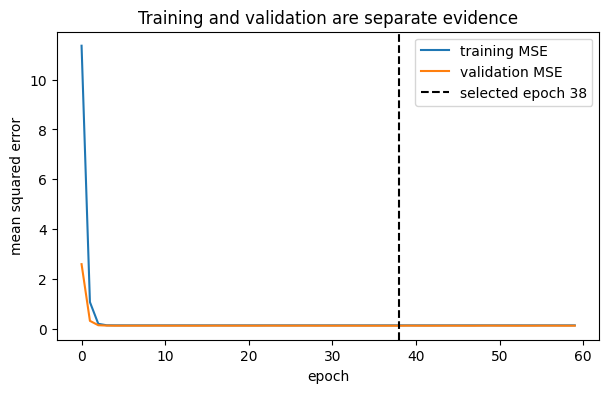

In [11]:
fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(training_history, label="training MSE")
axis.plot(validation_history, label="validation MSE")
axis.axvline(best_epoch, color="black", linestyle="--", label=f"selected epoch {best_epoch}")
axis.set_xlabel("epoch")
axis.set_ylabel("mean squared error")
axis.set_title("Training and validation are separate evidence")
axis.legend()
plt.show()


## 12 · A checkpoint needs weights, optimizer state, and metadata

A `state_dict` maps parameter and buffer names to tensors. It is safer and more
portable than treating an unexplained Python object as the artifact.

To resume training, save optimizer state too. To reproduce meaning, save metadata:

- architecture and input shape;
- feature order and preprocessing statistics;
- target definition;
- selected epoch and validation metric;
- seed, PyTorch version, and device type;
- data and code version in a real project.

We serialize to an in-memory byte buffer so the lesson leaves no checkpoint file in
the repository. Then we construct a fresh model and prove its predictions match.


In [12]:
checkpoint_metadata = {
    "input_feature_count": 3,
    "feature_order": ["sensor_a", "sensor_b", "sensor_c"],
    "training_feature_mean": training_feature_mean,
    "training_feature_std": training_feature_std,
    "selected_epoch": int(best_epoch),
    "best_validation_mse": float(best_validation_loss),
    "seed": 42,
    "torch_version": str(torch.__version__),
    "training_device": compute_device.type,
}
checkpoint = {
    "model_state": best_model_state,
    "optimizer_state": best_optimizer_state,
    "metadata": checkpoint_metadata,
}

checkpoint_buffer = io.BytesIO()
torch.save(checkpoint, checkpoint_buffer)
checkpoint_buffer.seek(0)
loaded_checkpoint = torch.load(
    checkpoint_buffer,
    map_location="cpu",
    weights_only=True,
)

loaded_model = TransparentLinearRegression(
    loaded_checkpoint["metadata"]["input_feature_count"]
)
loaded_model.load_state_dict(loaded_checkpoint["model_state"])
loaded_model.eval()

with torch.inference_mode():
    original_cpu_predictions = regression_model.to("cpu")(validation_features)
    loaded_predictions = loaded_model(validation_features)

print("checkpoint keys:", list(loaded_checkpoint.keys()))
print("state keys:", list(loaded_checkpoint["model_state"].keys()))
print("loaded predictions match:", torch.allclose(original_cpu_predictions, loaded_predictions))

assert torch.allclose(original_cpu_predictions, loaded_predictions)


checkpoint keys: ['model_state', 'optimizer_state', 'metadata']
state keys: ['linear.weight', 'linear.bias']
loaded predictions match: True


## 13 · Mini-project: restore the selected model and test once

**Goal:** train a transparent PyTorch regression model and produce one reproducible
sealed-test report.

**Dataset columns:** three numerical sensor features and one continuous energy target.

**Workflow:**

1. freeze train, validation, and test indices;
2. fit preprocessing on training only;
3. create shuffled training and ordered validation loaders;
4. train with a fully traced loop;
5. select an epoch from validation loss;
6. save model, optimizer, preprocessing, and metadata;
7. rebuild a fresh model and verify validation predictions;
8. create the test loader only after restoration;
9. report test RMSE once without retuning.

A training-mean prediction is the baseline. The test result estimates performance;
it does not select a new learning rate or epoch.


In [13]:
sealed_test_dataset = TensorDataset(sealed_test_features, sealed_test_targets)
sealed_test_loader = DataLoader(sealed_test_dataset, batch_size=128, shuffle=False)

final_test_mse, final_test_predictions = evaluate_regression(
    loaded_model,
    sealed_test_loader,
    regression_loss_function,
    torch.device("cpu"),
)
training_mean_baseline_predictions = torch.full_like(
    sealed_test_targets,
    train_targets.mean(),
)
baseline_test_mse = nn.functional.mse_loss(
    training_mean_baseline_predictions,
    sealed_test_targets,
).item()

final_report = pd.Series(
    {
        "selected_epoch": best_epoch,
        "test_rows": len(sealed_test_dataset),
        "baseline_test_RMSE": baseline_test_mse ** 0.5,
        "model_test_RMSE": final_test_mse ** 0.5,
    }
)
print(final_report.round(4))
print("final report only; test did not change model or checkpoint")

assert final_test_mse < baseline_test_mse
assert len(final_test_predictions) == len(sealed_test_targets)


selected_epoch         38.0000
test_rows             240.0000
baseline_test_RMSE      3.7919
model_test_RMSE         0.3511
dtype: float64
final report only; test did not change model or checkpoint


## 14 · Practice, solutions, and mastery checkpoint

### Worked example

Input batch `(32, 4)` enters `Linear(4, 8)`. Weight storage is `(8, 4)`, so the
layer calculates `(32, 4) @ (4, 8) + (8,)` and returns `(32, 8)`.

### Guided practice

1. Predict the result shape of `(5, 3) @ (3, 2) + (2,)`.
2. Explain `tensor[0]` versus `tensor[0:1]`.
3. Calculate the gradient of $(w-4)^2$ at $w=1$.
4. Explain why gradients accumulate.
5. Assign one job to training, validation, and test.

### Independent practice

6. Add MAE to evaluation without changing the optimization loss.
7. Replace SGD with Adam and record optimizer metadata.
8. Implement a custom `Dataset` that validates row shapes.
9. Resume training from the saved optimizer state on development data only.
10. Run the same checkpoint on CPU and an available accelerator; document tolerance.

### Challenge

Rebuild the regression project without copying. Include tensor contracts, a device
helper, autograd accumulation, custom module, three partitions, train-only scaling,
loaders, weighted loss aggregation, validation checkpointing, in-memory save/load,
prediction equivalence, and one sealed-test report.

### Self-check

1. When does `from_numpy` share memory?
2. Why can a transposed tensor be non-contiguous?
3. What does broadcasting do with a `(c,)` bias?
4. Does `backward()` update a parameter?
5. Why clear gradients before an ordinary step?
6. Why use both `eval()` and `inference_mode()`?
7. What must a resumable checkpoint contain?
8. Which partition may select the checkpoint epoch?

### Solution and scoring rubric

1. Result shape is `(5, 2)`.
2. `[0]` removes the batch axis; `[0:1]` preserves it.
3. Gradient is $2(1-4)=-6$.
4. Accumulation supports multiple backward contributions before an update.
5. Training updates; validation selects; test estimates once.

Award two points for each self-check and four points for the challenge explanation.
Full credit requires correct tensor, gradient, device, and data boundaries.

### Common mistakes

- Allowing an unexpected `float64` tensor into a `float32` model.
- Using floating class indices with cross-entropy.
- Losing the batch dimension with an unplanned `squeeze`.
- Assuming every reshaped or transposed view is contiguous.
- Moving the model but not the batch to an accelerator.
- Calling `backward()` and expecting it to update parameters.
- Forgetting to clear accumulated gradients.
- Applying softmax before `CrossEntropyLoss` in later classifiers.
- Shuffling or updating parameters in validation.
- Averaging batch losses without example weighting.
- Selecting a checkpoint from test loss.
- Saving weights without preprocessing and metadata.

### Readiness threshold

Score at least **16/20** and correctly trace shape, dtype, device, autograd,
optimizer, loader, validation checkpoint, serialization, and sealed-test behavior.


## Ready to move on?

### Quick check

Explain this chain without notes:

tensor contract  
→ shape and broadcast  
→ device  
→ autograd  
→ registered parameter  
→ Dataset and DataLoader  
→ training step  
→ evaluation loop  
→ validation checkpoint  
→ save and restore  
→ one sealed test.

### Teach it back

Trace one batch from loader to loss to gradient to optimizer update. Then explain
exactly what changes during evaluation and why test cannot choose a checkpoint.

### Memory aid

**Inspect every tensor, separate every partition, clear before backward, validate
before saving, and test only the restored state.**

### Next dependency

Tensor operations, modules, and verified training loops  
→ required before neural networks from scratch  
→ because DL-02 can now focus on why hidden layers work while preserving a reliable
experimental contract.
